**Yu-gi-oh Forecast**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [28]:
#read from dataset
df = pd.read_csv("yugioh_enriched.csv", usecols=['name', 'type','race','card_sets_set_name','card_sets_set_rarity_code','card_sets_set_price','card_prices_cardmarket_price','card_sets_set_code'])

#Replace String Characters
df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace('(','')
df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace(')','')

#If there are null rarities then set as common
df['card_sets_set_rarity_code']= df['card_sets_set_rarity_code'].fillna("C")
df.head(5)

C:\Users\19319\AppData\Local\Temp\ipykernel_19732\1805873827.py:5: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace('(','')
C:\Users\19319\AppData\Local\Temp\ipykernel_19732\1805873827.py:6: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['card_sets_set_rarity_code']= df.card_sets_set_rarity_code.str.replace(')','')


,name,type,race,card_sets_set_name,card_sets_set_code,card_sets_set_rarity_code,card_sets_set_price,card_prices_cardmarket_price
0,Tornado Dragon,XYZ Monster,Wyrm,Battles of Legend: Relentless Revenge,BLRR-EN084,ScR,4.65,0.19
1,Tornado Dragon,XYZ Monster,Wyrm,Duel Devastator,DUDE-EN019,UR,1.58,0.19
2,Tornado Dragon,XYZ Monster,Wyrm,Legendary Duelists: Synchro Storm,LED8-EN055,C,0.96,0.19
3,Tornado Dragon,XYZ Monster,Wyrm,Maximum Crisis,MACR-EN081,ScR,4.49,0.19
4,Exodia the Forbidden One,Effect Monster,Spellcaster,Dark Beginning 1,DB1-EN139,UR,40.10,0.46


In [72]:
#Grouped df price
df_grouped = df.groupby('card_sets_set_rarity_code').sum().sort_values('card_sets_set_price')
df_grouped

C:\Users\19319\AppData\Local\Temp\ipykernel_19732\15792226.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_grouped = df.groupby('card_sets_set_rarity_code').sum().sort_values('card_sets_set_price')


,card_sets_set_price,card_prices_cardmarket_price
card_sets_set_rarity_code,,
SFR,13.50,3.48
DUPR,28.71,0.18
UPR,87.42,0.04
PG,116.53,1.14
DRPR,133.02,0.36
MSR,140.67,6.73
GUR,149.43,8.83
GScR,242.58,8.37
UtR,276.63,1.17


In [30]:
#Grouped mean price
df_grouped_mean =df.groupby('card_sets_set_rarity_code').mean().sort_values('card_sets_set_price')
df_grouped_mean

C:\Users\19319\AppData\Local\Temp\ipykernel_19732\1512084478.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_grouped_mean =df.groupby('card_sets_set_rarity_code').mean().sort_values('card_sets_set_price')


,card_sets_set_price,card_prices_cardmarket_price
card_sets_set_rarity_code,,
C,2.096224,0.065714
DUPR,3.190000,0.020000
SFR,3.375000,0.870000
DRPR,7.390000,0.020000
GUR,7.864737,0.464737
PG,8.963846,0.087692
SR,10.799474,0.057368
GScR,13.476667,0.465000
MSR,15.630000,0.747778


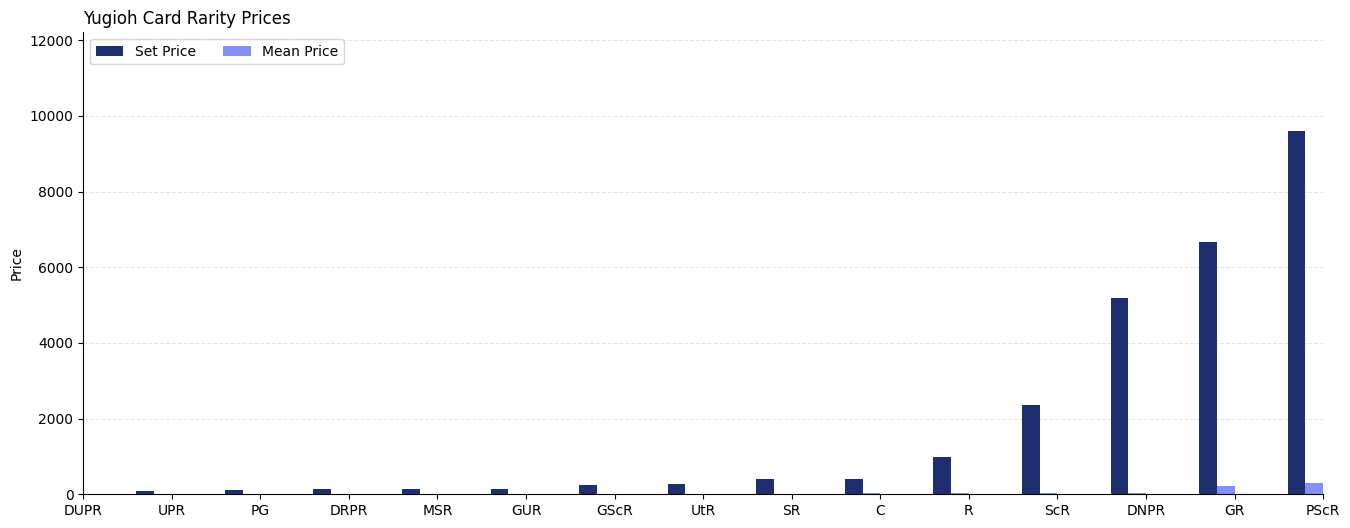

In [31]:
#Plot out average card price by rarity
# define figure
fig, ax = plt.subplots(1, figsize=(16, 6))# numerical x

x = np.arange(0, len(df_grouped.index))# plot bars
plt.bar(x - 0.3, df_grouped['card_sets_set_price'], width = 0.2, color = '#1D2F6F')
plt.bar(x - 0.1, df_grouped_mean['card_sets_set_price'], width = 0.2, color = '#8390FA')

# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# x y details
plt.ylabel('Price')
plt.xticks(x, df_grouped.index)
plt.xlim(1, 15)
# grid lines
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.2)# title and legend
plt.title('Yugioh Card Rarity Prices', loc ='left')
plt.legend(['Set Price','Mean Price'], loc='upper left', ncol = 2)
plt.show()

In [32]:
#Check missing data
df.isnull().values.any()

False

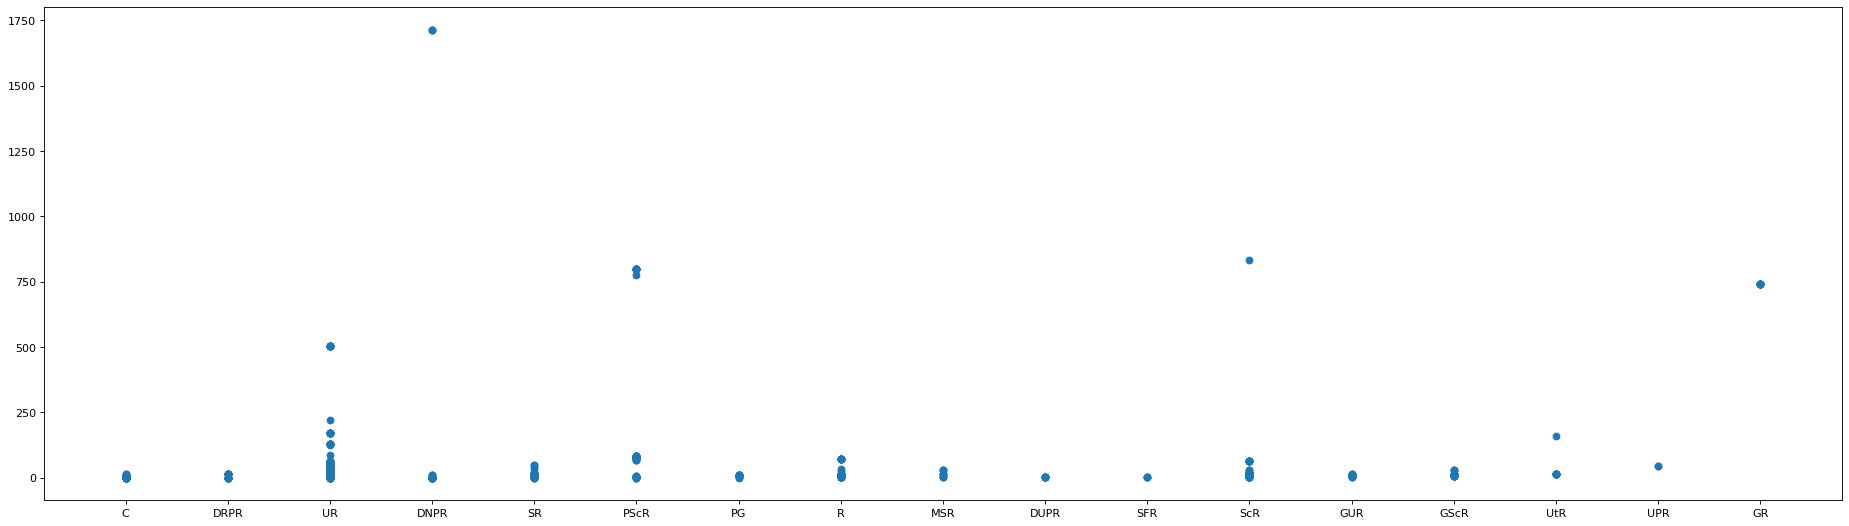

In [33]:
df = df.sort_values('card_sets_set_price')
plt.figure(figsize=(29, 8), dpi=80)
plt.scatter(df['card_sets_set_rarity_code'].astype(str),df['card_sets_set_price'])

In [34]:
df.dtypes

name                             object
type                             object
race                             object
card_sets_set_name               object
card_sets_set_code               object
card_sets_set_rarity_code        object
card_sets_set_price             float64
card_prices_cardmarket_price    float64
dtype: object

**What is K-Fold cross validation?** 

Cross-validation is a statistical method used to estimate the skill of machine learning models.
That k-fold cross validation is a procedure used to estimate the skill of the model on new data.
There are common tactics that you can use to select the value of k for your dataset.
There are commonly used variations on cross-validation such as stratified and repeated that are available in scikit-learn

In [ ]:
#Identify measure values for predictions
X = pd.DataFrame(df['card_prices_cardmarket_price']).dropna()
y = pd.DataFrame(df['card_sets_set_price'])

# Scale the data
scaler = preprocessing.StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

In [50]:
X.shape, y.shape

((795, 1), (795, 1))

Coefficients: 
 [[-0.07586335]]
Mean squared error: 0.87
Mean absolute error: 0.42
Coefficient of determination: -0.01


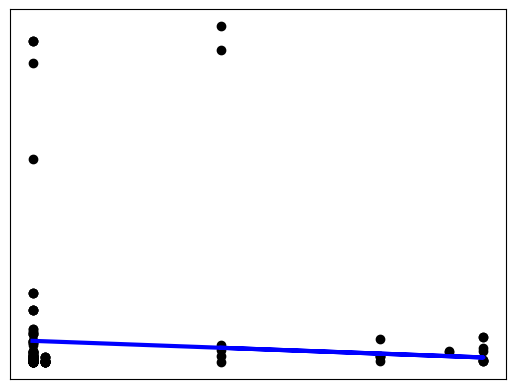

Coefficients: 
 [[-0.0682972]]
Mean squared error: 0.42
Mean absolute error: 0.35
Coefficient of determination: -0.05


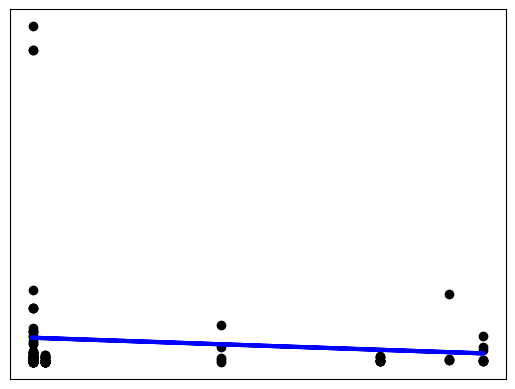

Coefficients: 
 [[-0.0459985]]
Mean squared error: 1.82
Mean absolute error: 0.46
Coefficient of determination: 0.00


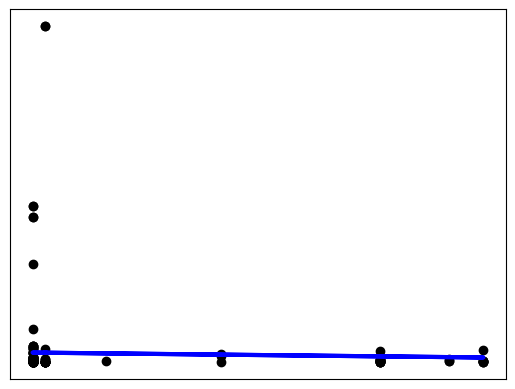

Coefficients: 
 [[-0.05277081]]
Mean squared error: 0.68
Mean absolute error: 0.39
Coefficient of determination: 0.01


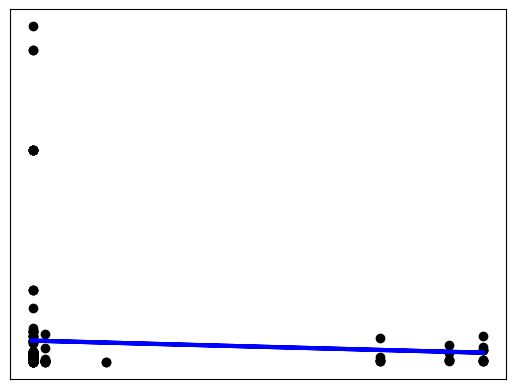

Coefficients: 
 [[-0.05737956]]
Mean squared error: 1.21
Mean absolute error: 0.41
Coefficient of determination: 0.00


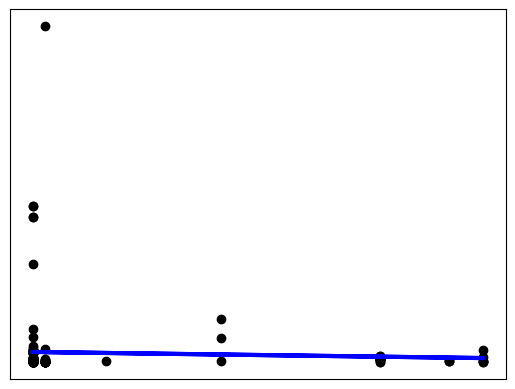

              name            type         race  \
669   Mystical Elf  Normal Monster  Spellcaster   
174  Dark Magician  Normal Monster  Spellcaster   
101  Dark Magician  Normal Monster  Spellcaster   
100  Dark Magician  Normal Monster  Spellcaster   
99   Dark Magician  Normal Monster  Spellcaster   

                      card_sets_set_name card_sets_set_code  \
669                       Demo Deck 2016         DEM3-EN001   
174  KC Grand Tournament 2021 prize card         2021-EN001   
101       Duel Terminal - Preview Wave 2         DTP1-EN002   
100       Duel Terminal - Preview Wave 2         DTP1-EN002   
99        Duel Terminal - Preview Wave 2         DTP1-EN002   

    card_sets_set_rarity_code  card_sets_set_price  \
669                         C                  0.0   
174                         C                  0.0   
101                      DRPR                  0.0   
100                      DRPR                  0.0   
99                       DRPR               

In [78]:
# Use separate scalers for X and y
scaler_X = preprocessing.StandardScaler()
scaler_y = preprocessing.StandardScaler()

# Drop rows where either X or y is NaN to keep alignment
xy = df[['card_prices_cardmarket_price', 'card_sets_set_price']].dropna()
X_scaled = scaler_X.fit_transform(xy[['card_prices_cardmarket_price']])
y_scaled = scaler_y.fit_transform(xy[['card_sets_set_price']])

model = LinearRegression()
scores = []
all_pred_dfs = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train, test) in enumerate(kfold.split(X_scaled, y_scaled)):
    model.fit(X_scaled[train], y_scaled[train])
    score = model.score(X_scaled[test], y_scaled[test])
    y_pred = model.predict(X_scaled[test])
    scores.append(score)
    
    # The coefficients
    print("Coefficients: \n", model.coef_)
    # The mean squared error
    print("Mean squared error: %.2f" % mean_squared_error(y_scaled[test], y_pred))
    # The mean absolute error
    print("Mean absolute error: %.2f" % mean_absolute_error(y_scaled[test], y_pred))
    # The coefficient of determination: 1 is perfect prediction
    print("Coefficient of determination: %.2f" % r2_score(y_scaled[test], y_pred))
    
    # Plot outputs
    plt.scatter(X_scaled[test], y_scaled[test], color="black")
    plt.plot(X_scaled[test], y_pred, color="blue", linewidth=3)

    plt.xticks(())
    plt.yticks(())

    plt.show()
    
    # Inverse transform predictions and actual values using the correct scalers
    y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1))
    y_test_original = scaler_y.inverse_transform(y_scaled[test])
    # Inverse transform predictions and actual values using the correct scalers
    y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1))
    y_test_original = scaler_y.inverse_transform(y_scaled[test])

    # Shift predictions and actuals so the minimum value is 0 after inverse transform
    min_pred = y_pred_original.min()
    min_true = y_test_original.min()
    shift = min(min_pred, min_true)
    y_pred_original = y_pred_original - shift
    y_test_original = y_test_original - shift
    
    # Note: StandardScaler centers data to mean 0 and scales to unit variance.
    # If your original data's minimum is 0, the transformed values can be negative
    # because StandardScaler subtracts the mean before dividing by std.
    # This is expected behavior for StandardScaler.

    # Create a DataFrame for predictions
    # Use xy (the filtered DataFrame) to get the correct indices for test set
    test_indices = xy.iloc[test].index

    pred_df = pd.DataFrame({
        'card_prices_cardmarket_price': X_test_original.flatten(),
        'actual_set_price': y_test_original.flatten(),
        'predicted_set_price': y_pred_original.flatten()
    }, index=test_indices)

    all_pred_dfs.append(pred_df)

# Join all predictions to the original dataframe
all_preds = pd.concat(all_pred_dfs)

# Use join only on the index that matches, otherwise use merge
df_with_preds = df.copy()
for col in all_preds.columns:
    df_with_preds.loc[all_preds.index, col] = all_preds[col]

print(df_with_preds.head())
print(scores)


In [77]:
pred_df

,card_prices_cardmarket_price,actual_set_price,predicted_set_price
174,0.02,0.00,52.227068
99,0.02,0.00,52.227068
94,0.02,0.00,52.227068
93,0.02,0.00,52.227068
87,0.02,0.00,52.227068
...,...,...,...
164,0.02,742.00,52.227068
160,0.02,742.00,52.227068
391,0.02,797.61,52.227068
396,0.02,797.61,52.227068


In [74]:
y_scaled

array([[-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.89716524e-01],
       [-2.8